# 03 — Delay cause attribution

Uses `cleaned_flight_data.csv` from notebook **01**. Summarizes how much each official delay category contributes overall and by airline, origin airport, month, and season. Exports summary tables for reporting and dashboard prep.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

CAUSES = [
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay",
]
CAUSE_LABELS = ["Carrier", "Weather", "NAS", "Security", "Late aircraft"]

In [2]:
df = pd.read_csv("cleaned_flight_data.csv", low_memory=False)
df["FlightDate"] = pd.to_datetime(df["FlightDate"], errors="coerce")

for c in CAUSES:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

if "TotalCauseDelay" not in df.columns:
    df["TotalCauseDelay"] = df[CAUSES].sum(axis=1)

if "IsArrivalDelayed" not in df.columns:
    df["IsArrivalDelayed"] = pd.to_numeric(df["ArrDelay"], errors="coerce").fillna(0) > 0
else:
    df["IsArrivalDelayed"] = df["IsArrivalDelayed"].astype(bool)

if "Season" not in df.columns:
    m = df["FlightDate"].dt.month
    df["Season"] = np.select(
        [m.isin([12, 1, 2]), m.isin([3, 4, 5]), m.isin([6, 7, 8])],
        ["Winter", "Spring", "Summer"],
        default="Autumn",
    )

oper = df[df["Cancelled"] == 0].copy()
oper["ArrDelay"] = pd.to_numeric(oper["ArrDelay"], errors="coerce")

## A — Overall attribution (total minutes and % share)

In [3]:
totals = oper[CAUSES].sum()
grand = totals.sum()
pct = (totals / grand * 100).round(2)
overall = pd.DataFrame({"total_minutes": totals, "pct_of_all_cause_delay": pct})
overall

,total_minutes,pct_of_all_cause_delay
CarrierDelay,3746825.0,29.45
WeatherDelay,652085.0,5.13
NASDelay,3413414.0,26.83
SecurityDelay,18825.0,0.15
LateAircraftDelay,4891681.0,38.45


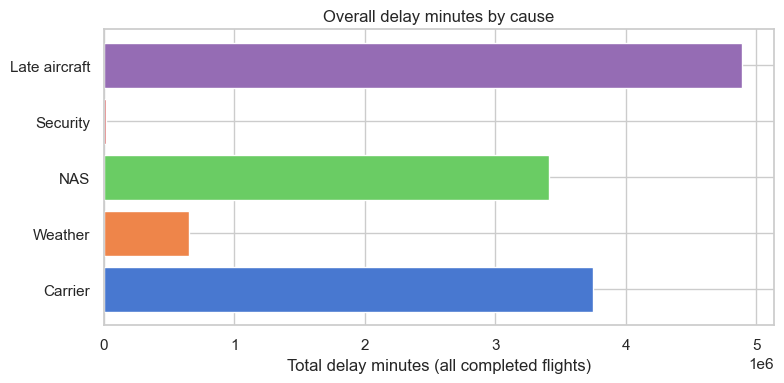

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(CAUSE_LABELS, totals.values, color=sns.color_palette("muted", len(CAUSES)))
ax.set_xlabel("Total delay minutes (all completed flights)")
ax.set_title("Overall delay minutes by cause")
plt.tight_layout()
plt.show()

## B — By airline (mean and total per cause; % of airline cause minutes)

In [5]:
g_air = oper.groupby("Reporting_Airline", observed=True)
sum_c = g_air[CAUSES].sum()
mean_c = g_air[CAUSES].mean()
row_sum = sum_c.sum(axis=1).replace(0, np.nan)
pct_air = sum_c.div(row_sum, axis=0) * 100

airline_delay_summary = mean_c.add_prefix("avg_")
for c in CAUSES:
    airline_delay_summary[f"total_{c}"] = sum_c[c]
for c in CAUSES:
    airline_delay_summary[f"pct_{c}"] = pct_air[c].round(2)
airline_delay_summary["flights"] = g_air.size()
airline_delay_summary = airline_delay_summary.reset_index()
airline_delay_summary.head(10)

,Reporting_Airline,avg_CarrierDelay,avg_WeatherDelay,avg_NASDelay,avg_SecurityDelay,avg_LateAircraftDelay,total_CarrierDelay,total_WeatherDelay,total_NASDelay,total_SecurityDelay,total_LateAircraftDelay,pct_CarrierDelay,pct_WeatherDelay,pct_NASDelay,pct_SecurityDelay,pct_LateAircraftDelay,flights
0,9E,3.586770,0.594549,3.117730,0.011277,4.020727,68701.0,11388.0,59717.0,216.0,77013.0,31.65,5.25,27.51,0.10,35.48,19154
1,AA,1.965606,0.368859,1.733056,0.009161,2.222065,452736.0,84959.0,399173.0,2110.0,511806.0,31.21,5.86,27.51,0.15,35.28,230329
2,AS,1.647834,0.115917,1.302128,0.029536,2.006520,80617.0,5671.0,63704.0,1445.0,98165.0,32.30,2.27,25.52,0.58,39.33,48923
3,B6,4.421219,0.447520,4.585505,0.039937,6.351119,163731.0,16573.0,169815.0,1479.0,235201.0,27.90,2.82,28.94,0.25,40.08,37033
4,CO,0.789940,0.127940,1.543011,0.011394,0.883320,70856.0,11476.0,138405.0,1022.0,79232.0,23.54,3.81,45.98,0.34,26.32,89698
5,DH,2.029666,0.489631,3.350374,0.001008,4.861319,14094.0,3400.0,23265.0,7.0,33757.0,18.91,4.56,31.22,0.01,45.30,6944
6,DL,1.491169,0.254138,1.420159,0.002691,1.373757,389037.0,66303.0,370511.0,702.0,358405.0,32.83,5.60,31.27,0.06,30.25,260894
7,EA,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,9068
8,EV,5.306233,0.895279,3.668425,0.007410,5.139882,348004.0,58716.0,240590.0,486.0,337094.0,35.33,5.96,24.43,0.05,34.23,65584
9,F9,3.165009,0.246420,4.072099,0.000494,5.312099,44864.0,3493.0,57722.0,7.0,75299.0,24.73,1.93,31.82,0.00,41.51,14175


## C — By origin airport (averages, delay rate, dominant cause)

In [6]:
g_ap = oper.groupby("Origin", observed=True)
sum_ap = g_ap[CAUSES].sum()
mean_ap = g_ap[CAUSES].mean()
delay_rate = g_ap["IsArrivalDelayed"].mean()
dominant = sum_ap.idxmax(axis=1)

airport_delay_summary = mean_ap.add_prefix("avg_")
for c in CAUSES:
    airport_delay_summary[f"total_{c}"] = sum_ap[c]
airport_delay_summary["delay_rate"] = delay_rate
airport_delay_summary["dominant_cause"] = dominant.values
airport_delay_summary["flights"] = g_ap.size()
airport_delay_summary = airport_delay_summary.reset_index()
airport_delay_summary.head(10)

,Origin,avg_CarrierDelay,avg_WeatherDelay,avg_NASDelay,avg_SecurityDelay,avg_LateAircraftDelay,total_CarrierDelay,total_WeatherDelay,total_NASDelay,total_SecurityDelay,total_LateAircraftDelay,delay_rate,dominant_cause,flights
0,ABE,1.795739,0.127820,1.834586,0.000000,1.770677,2866.0,204.0,2928.0,0.0,2826.0,0.402256,NASDelay,1596
1,ABI,3.861472,0.733766,1.251082,0.000000,2.595238,1784.0,339.0,578.0,0.0,1199.0,0.309524,CarrierDelay,462
2,ABQ,0.961592,0.167826,0.760089,0.004824,2.213471,10365.0,1809.0,8193.0,52.0,23859.0,0.423138,LateAircraftDelay,10779
3,ABR,22.987500,0.912500,0.825000,0.112500,4.325000,1839.0,73.0,66.0,9.0,346.0,0.275000,CarrierDelay,80
4,ABY,5.978022,0.593407,4.335165,0.000000,5.016484,1088.0,108.0,789.0,0.0,913.0,0.489011,CarrierDelay,182
5,ACK,0.726027,0.000000,21.465753,0.123288,8.986301,53.0,0.0,1567.0,9.0,656.0,0.520548,NASDelay,73
6,ACT,2.498462,0.372308,1.178462,0.000000,1.880000,812.0,121.0,383.0,0.0,611.0,0.289231,CarrierDelay,325
7,ACV,3.047710,0.185115,4.419847,0.000000,8.288168,1597.0,97.0,2316.0,0.0,4343.0,0.391221,LateAircraftDelay,524
8,ACY,3.844444,0.092593,3.451852,0.000000,4.051852,1038.0,25.0,932.0,0.0,1094.0,0.351852,LateAircraftDelay,270
9,ADK,1.045455,0.000000,0.000000,1.272727,2.181818,23.0,0.0,0.0,28.0,48.0,0.409091,LateAircraftDelay,22


## D — By month and season (average and total per cause)

In [7]:
by_month = oper.groupby("Month", observed=False)
by_season = oper.groupby("Season", observed=True)

def pack_time(gb, name):
    s = gb[CAUSES].sum().add_prefix("total_")
    m = gb[CAUSES].mean().add_prefix("avg_")
    out = pd.concat([s, m], axis=1)
    out.insert(0, "time_grain", name)
    return out.reset_index()

seasonal_delay_summary = pd.concat(
    [
        pack_time(by_month, "month").rename(columns={"Month": "period"}),
        pack_time(by_season, "season").rename(columns={"Season": "period"}),
    ],
    ignore_index=True,
)
seasonal_delay_summary.head(8)

,period,time_grain,total_CarrierDelay,total_WeatherDelay,total_NASDelay,total_SecurityDelay,total_LateAircraftDelay,avg_CarrierDelay,avg_WeatherDelay,avg_NASDelay,avg_SecurityDelay,avg_LateAircraftDelay
0,1,month,316121.0,70754.0,288040.0,1545.0,390854.0,1.921241,0.430011,1.750577,0.009390,2.375435
1,2,month,296594.0,59163.0,262894.0,1661.0,369627.0,1.958350,0.390641,1.735835,0.010967,2.440572
2,3,month,316035.0,41577.0,275069.0,1357.0,402761.0,1.849012,0.243253,1.609334,0.007939,2.356416
3,4,month,278439.0,46922.0,252849.0,977.0,360720.0,1.730746,0.291662,1.571682,0.006073,2.242196
4,5,month,279875.0,50593.0,281570.0,846.0,388850.0,1.699746,0.307263,1.710040,0.005138,2.361576
5,6,month,393010.0,78076.0,356280.0,1566.0,563800.0,2.402864,0.477357,2.178297,0.009575,3.447074
6,7,month,408306.0,77973.0,362898.0,1784.0,567787.0,2.416784,0.461526,2.148012,0.010560,3.360760
7,8,month,350063.0,62509.0,317350.0,3034.0,480301.0,2.067513,0.369185,1.874306,0.017919,2.836714


## E — Route-level snapshot (routes with at least 2 000 flights)

In [8]:
if "Route" not in oper.columns:
    oper["Route"] = oper["Origin"].astype(str) + "-" + oper["Dest"].astype(str)

rc = oper.groupby("Route", observed=True).agg(
    flights=("Route", "size"),
    avg_arr_delay=("ArrDelay", "mean"),
    **{f"avg_{c}": (c, "mean") for c in CAUSES},
)
route_delay_summary = rc[rc["flights"] >= 2000].sort_values("avg_arr_delay", ascending=False)
route_delay_summary.head(15)

,flights,avg_arr_delay,avg_CarrierDelay,avg_WeatherDelay,avg_NASDelay,avg_SecurityDelay,avg_LateAircraftDelay
Route,,,,,,,
ATL-EWR,2116,14.940702,1.094991,0.336957,7.661153,0.000000,2.644140
ORD-EWR,2650,13.537704,1.259623,0.325660,5.064906,0.000000,2.798868
ORD-SFO,2207,13.458012,2.970095,0.872225,4.138650,0.005437,3.277753
ATL-ORD,2560,11.797964,1.675000,0.630859,3.582031,0.003125,2.409766
SAN-SFO,2053,11.679024,0.672674,0.104725,4.474915,0.000000,3.062835
SEA-SFO,2405,11.623696,1.282328,0.303119,3.940956,0.000000,1.861954
ORD-BOS,2446,11.550736,1.746934,0.352003,2.714227,0.000000,3.575634
ORD-DEN,2040,11.513977,1.983333,1.150000,1.534314,0.000000,3.048529
ORD-ATL,2648,11.242711,2.005665,0.308157,2.606873,0.000000,3.518505


## Charts (stacked bars, heatmaps, top airports by cause)

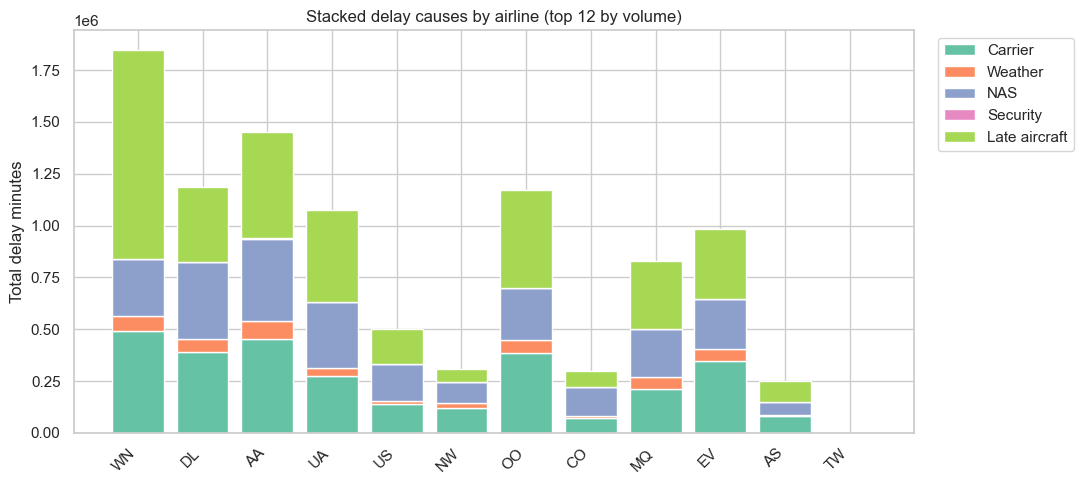

In [9]:
top_n = 12
air_order = airline_delay_summary.nlargest(top_n, "flights")["Reporting_Airline"]
sub = sum_c.loc[air_order]

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(sub))
colors = sns.color_palette("Set2", len(CAUSES))
for i, c in enumerate(CAUSES):
    ax.bar(sub.index.astype(str), sub[c].values, bottom=bottom, label=CAUSE_LABELS[i], color=colors[i])
    bottom += sub[c].values
ax.set_ylabel("Total delay minutes")
ax.set_title("Stacked delay causes by airline (top 12 by volume)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

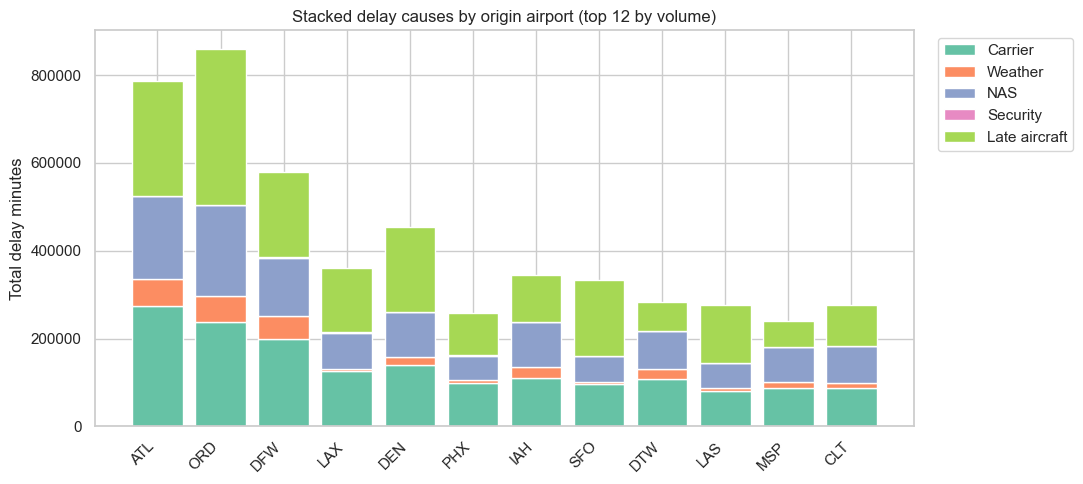

In [10]:
ap_order = airport_delay_summary.nlargest(top_n, "flights")["Origin"]
sub_ap = sum_ap.loc[ap_order]

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(sub_ap))
for i, c in enumerate(CAUSES):
    ax.bar(sub_ap.index.astype(str), sub_ap[c].values, bottom=bottom, label=CAUSE_LABELS[i], color=colors[i])
    bottom += sub_ap[c].values
ax.set_ylabel("Total delay minutes")
ax.set_title("Stacked delay causes by origin airport (top 12 by volume)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

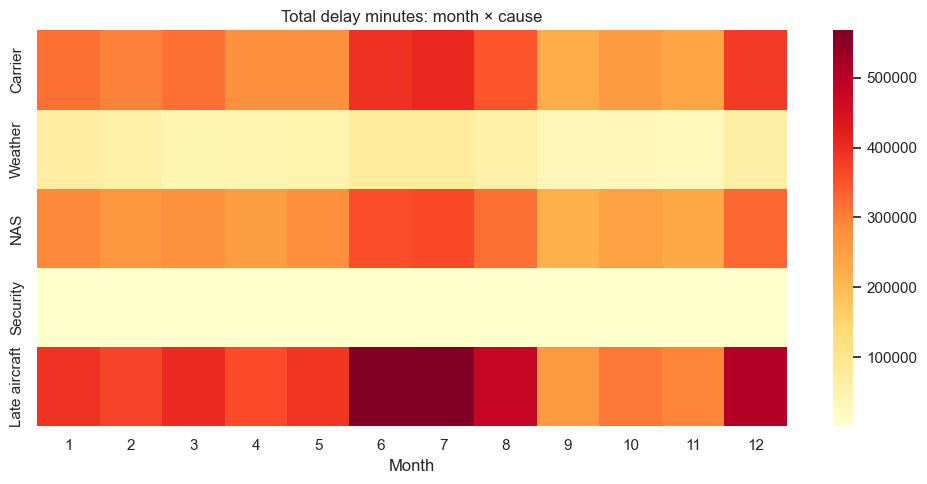

In [11]:
m_sum = oper.groupby("Month", observed=False)[CAUSES].sum()
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(m_sum.T, cmap="YlOrRd", ax=ax, yticklabels=CAUSE_LABELS)
ax.set_title("Total delay minutes: month × cause")
ax.set_xlabel("Month")
plt.tight_layout()
plt.show()

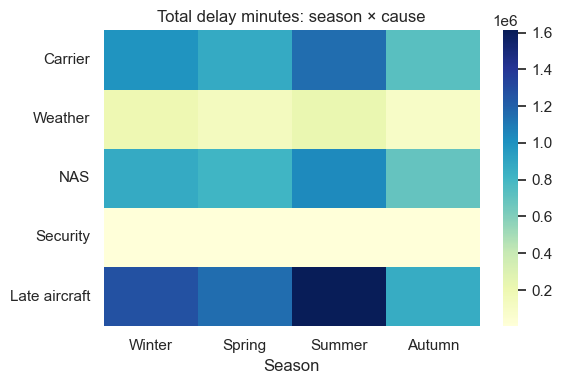

In [12]:
s_sum = oper.groupby("Season", observed=True)[CAUSES].sum()
s_sum = s_sum.reindex(["Winter", "Spring", "Summer", "Autumn"], fill_value=0)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(s_sum.T, cmap="YlGnBu", ax=ax, yticklabels=CAUSE_LABELS)
ax.set_title("Total delay minutes: season × cause")
plt.tight_layout()
plt.show()

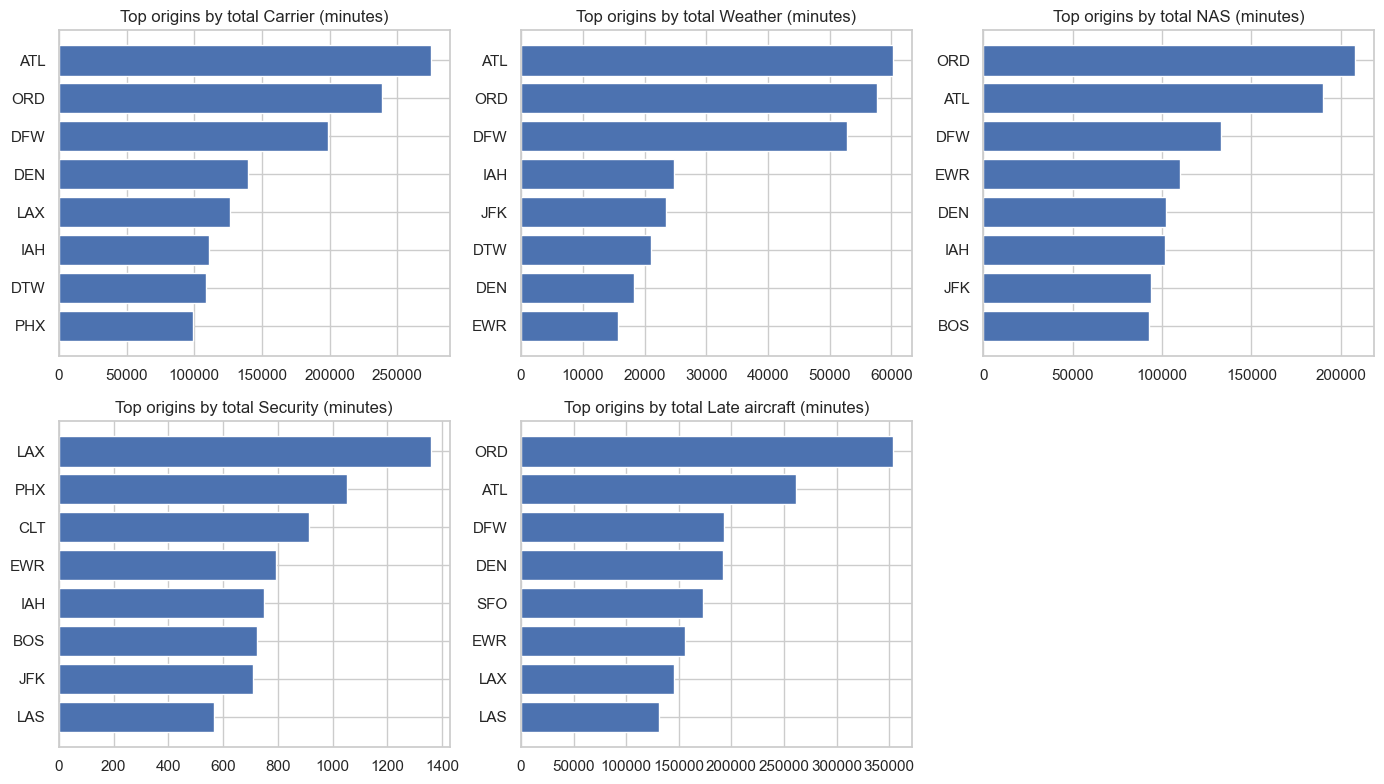

In [13]:
min_fl = 500
valid_origins = set(airport_delay_summary.loc[airport_delay_summary["flights"] >= min_fl, "Origin"])
by_origin_sum = oper.groupby("Origin", observed=True)[CAUSES].sum()
by_origin_sum = by_origin_sum[by_origin_sum.index.isin(valid_origins)]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for ax, c, lab in zip(axes[:-1], CAUSES, CAUSE_LABELS):
    top = by_origin_sum[c].nlargest(8)
    ax.barh(top.index.astype(str), top.values, color="#4c72b0")
    ax.invert_yaxis()
    ax.set_title(f"Top origins by total {lab} (minutes)")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

## Export CSV summaries

In [14]:
delay_cause_summary = overall.reset_index().rename(columns={"index": "cause"})
delay_cause_summary["cause"] = delay_cause_summary["cause"].map(dict(zip(CAUSES, CAUSE_LABELS)))

delay_cause_summary.to_csv("delay_cause_summary.csv", index=False)
airline_delay_summary.to_csv("airline_delay_summary.csv", index=False)
airport_delay_summary.to_csv("airport_delay_summary.csv", index=False)
seasonal_delay_summary.to_csv("seasonal_delay_summary.csv", index=False)